In [31]:
""" Imports """
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, mean_squared_error

from simulation_encoder.loaders.loader_retrieval import load_loaders
from simulation_encoder.models.model_retrieval import load_models

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
study_name = "legacy/arch_simple_gastruloid_processed_16_simple"
image_dir = "data"
num_timepoints = 9

results_dir = f"results/{study_name}"

all_models = load_models(results_dir, num_timepoints=num_timepoints, best_models_flag=True)
all_loaders = load_loaders(results_dir, image_dir)

print(f"Models: {list(all_models.keys())}")
print(f"Datasets: {list(all_loaders.keys())}")

all_samples = {}
all_labels = {}
data_loaders = {}
random_indices = {}

for dataset_name, loader in all_loaders.items():
    data_loaders[dataset_name] = {
        "train": loader.get_dataloader('train'),
        "val": loader.get_dataloader('val'),
        "test": loader.get_dataloader('test'),
        "full": loader,
    }

Loading model ae_simple (7.27e+07 parameters)
Loading model cae (3.38e+07 parameters)
Loading model neuralop_simple (6.75e+07 parameters)
Models: ['ae', 'cae', 'neuralop']
Datasets: ['gastruloid_processed_128']


In [33]:
nn_embeddings = {}

for model_name, datasets in all_models.items():
    nn_embeddings[model_name] = {}
    for dataset_name, model in datasets.items():
        nn_embeddings[model_name][dataset_name] = {}
        print(model_name, dataset_name)
            
        train_loader = data_loaders[dataset_name]["train"]
        val_loader = data_loaders[dataset_name]["val"]
        test_loader = data_loaders[dataset_name]["test"]
        num_dimensions = model.latent_dim

        model.eval()
        with torch.no_grad():
            encoded_samples = []
            # for inputs, _ in train_loader:
            #     encoded_batch = model.encode(inputs)
            #     encoded_samples.append(encoded_batch)
            # for inputs, _ in val_loader:
            #     encoded_batch = model.encode(inputs)
            #     encoded_samples.append(encoded_batch)
            for inputs, _ in test_loader:
                encoded_batch = model.encode(inputs)
                encoded_samples.append(encoded_batch)
            encoded_samples = torch.cat(encoded_samples, dim=0)

        
        nn_embeddings[model_name][dataset_name] = encoded_samples

ae gastruloid_processed_128
cae gastruloid_processed_128
neuralop gastruloid_processed_128


In [34]:
pca_embeddings = {}
for model_name, dataset in nn_embeddings.items():
    pca_embeddings[model_name] = {}
    for dataset_name, embeddings in dataset.items():
        pca = PCA(n_components=2)
        pca_embeddings[model_name][dataset_name] = pca.fit_transform(embeddings)

        print(f"{model_name} | {dataset_name} - Explained Variance: {pca.explained_variance_ratio_}")

ae | gastruloid_processed_128 - Explained Variance: [0.37120865 0.22172829]
cae | gastruloid_processed_128 - Explained Variance: [0.39468135 0.24752865]
neuralop | gastruloid_processed_128 - Explained Variance: [0.35778577 0.27685003]


In [35]:
timepoints = {}
array_nums = {}
raft_ids = {}
for model_name, dataset in all_models.items():
    array_nums[model_name] = {}
    raft_ids[model_name] = {}
    timepoints[model_name] = {}
    for dataset_name, model in dataset.items():
        array_nums[model_name][dataset_name] = []
        raft_ids[model_name][dataset_name] = []
        timepoints[model_name][dataset_name] = []

        loader = data_loaders[dataset_name]["full"]
        # for idx in loader._train_indices:
        #     sample_id = loader._get_data_feature(idx, 'sample_id')
        #     array, raft_num = sample_id.split('_')
        #     array_num = int(array[-1])
        #     raft_num = int(raft_num)
        #     array_nums[model_name][dataset_name].append(array_num)
        #     raft_ids[model_name][dataset_name].append(raft_num)
        #     timepoints[model_name][dataset_name].append(int(loader._get_data_feature(idx, 'timepoint')))
        
        # for idx in loader._val_indices:
        #     sample_id = loader._get_data_feature(idx, 'sample_id')
        #     array, raft_num = sample_id.split('_')
        #     array_num = int(array[-1])
        #     raft_num = int(raft_num)
        #     array_nums[model_name][dataset_name].append(array_num)
        #     raft_ids[model_name][dataset_name].append(raft_num)
        #     timepoints[model_name][dataset_name].append(int(loader._get_data_feature(idx, 'timepoint')))

        for idx in loader._test_indices:
            sample_id = loader._get_data_feature(idx, 'sample_id')
            array, raft_num = sample_id.split('_')
            array_num = int(array[-1])
            raft_num = int(raft_num)
            array_nums[model_name][dataset_name].append(array_num)
            raft_ids[model_name][dataset_name].append(raft_num)
            timepoints[model_name][dataset_name].append(int(loader._get_data_feature(idx, 'timepoint')))

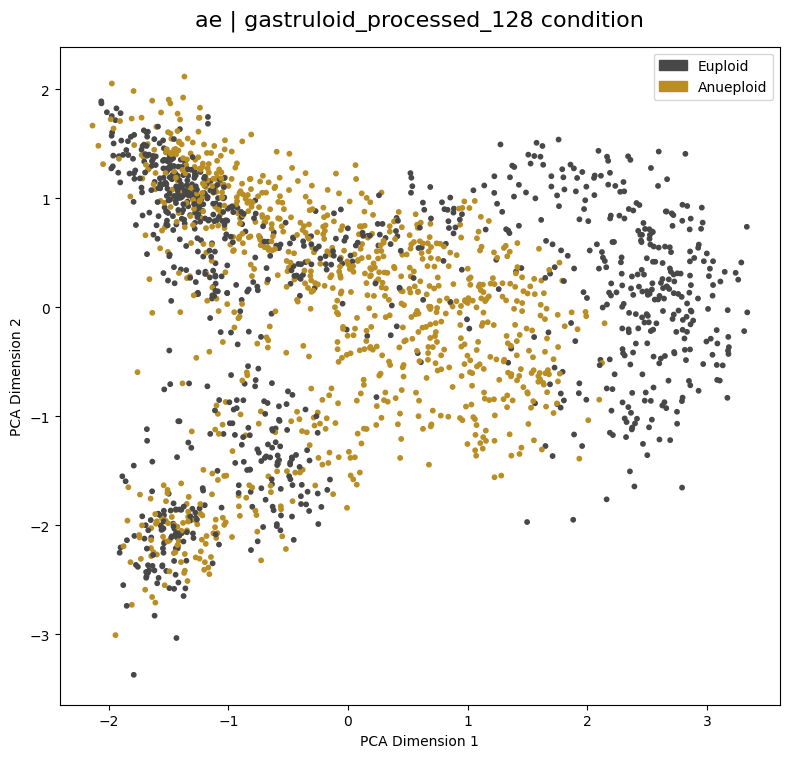

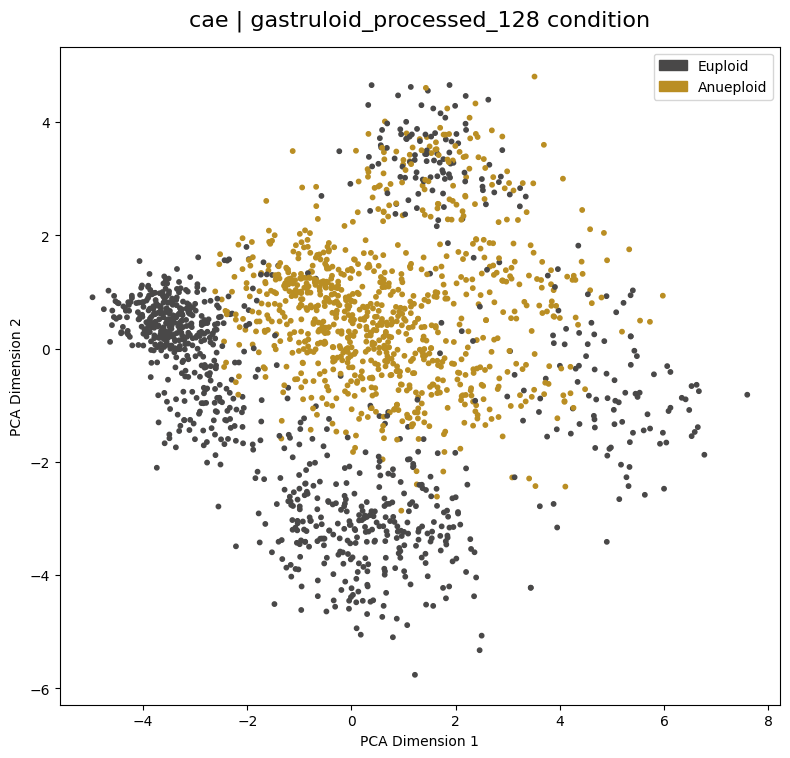

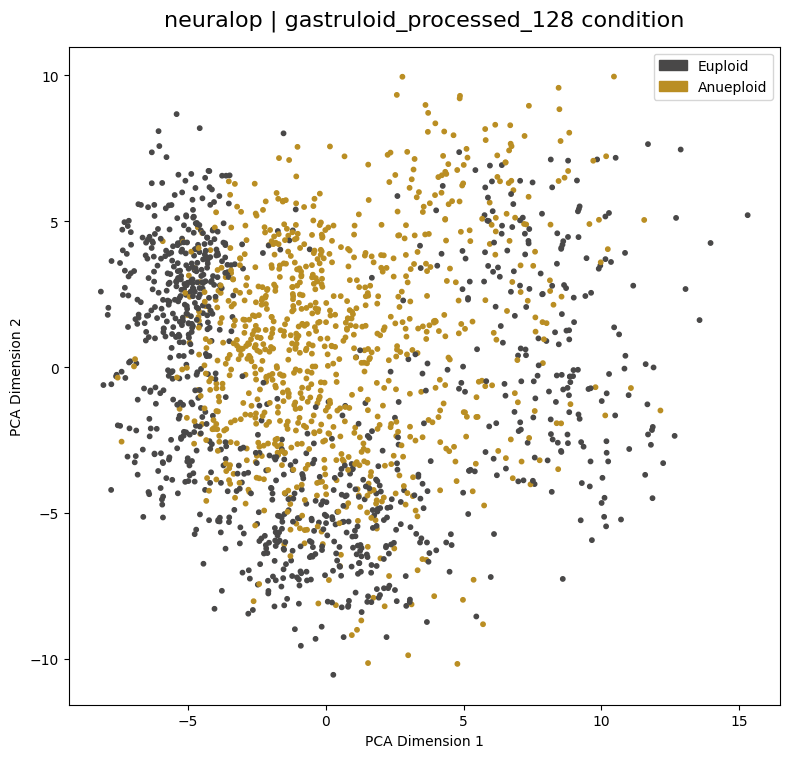

In [36]:
base_colors = {1: "#494848", 2: "#BA8E23"}

def make_segments(x, y):
    """Create line segments from x and y coordinates."""
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    return segments

def colorline(x, y, z, cmap, linewidth=1, alpha=0.5):
    """Plot a line with coordinates x and y using a colormap."""
    z = np.asarray(z)
    segments = make_segments(x, y)
    
    # Use z[1:] to assign each segment the color of its second point
    lc = LineCollection(segments, array=z[1:], cmap=cmap, linewidth=linewidth, linestyles="dashed", alpha=alpha)
    
    ax = plt.gca()
    ax.add_collection(lc)

def create_colormap(base_color, n=256, light_boost=0.85, dark_boost=0.85):
    """Enhances the colormap by making light colors lighter and dark colors darker."""
    return ListedColormap([
        [min(1.0, c + (1 - c) * (light_boost - dark_boost * t**1.5)) for c in base_color]
        for t in np.linspace(0, 1, n)
    ])

for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():
        pca_embedding = pca_embeddings[model_name][dataset_name]
        rafts_list = array_nums[model_name][dataset_name]

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.scatter(pca_embedding[:, 0], pca_embedding[:, 1], c=[base_colors[raft] for raft in rafts_list], s=10)

        ax.set_title(f'{model_name} | {dataset_name} condition', fontsize=16, y=1.02)
        ax.set_xlabel('PCA Dimension 1')
        ax.set_ylabel('PCA Dimension 2')

        legend_handles = [
            mpatches.Patch(color=base_colors[1], label='Euploid'),
            mpatches.Patch(color=base_colors[2], label='Anueploid')
        ]
        ax.legend(handles=legend_handles, loc='upper right')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

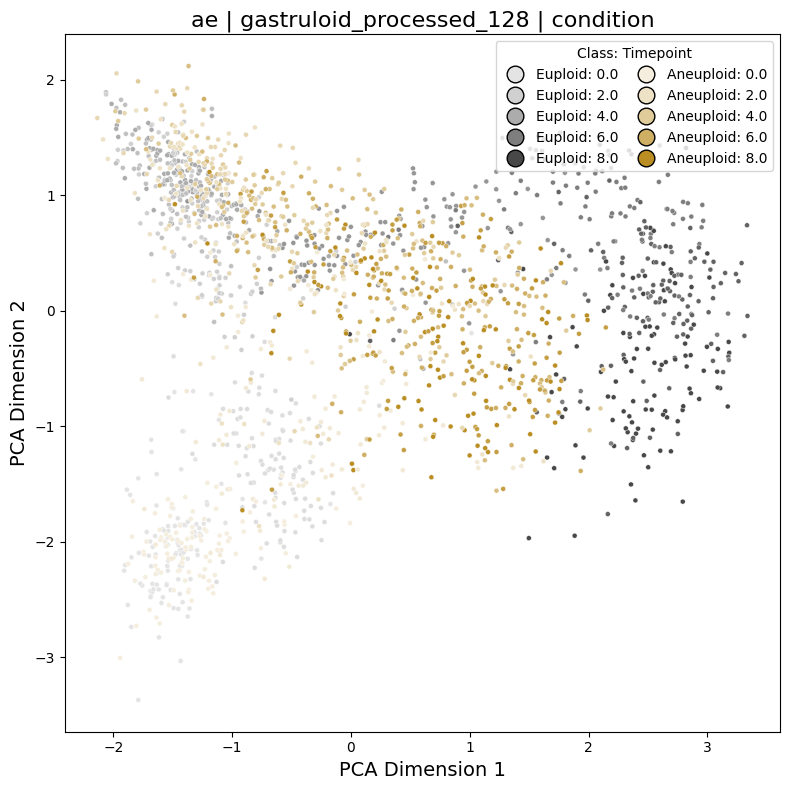

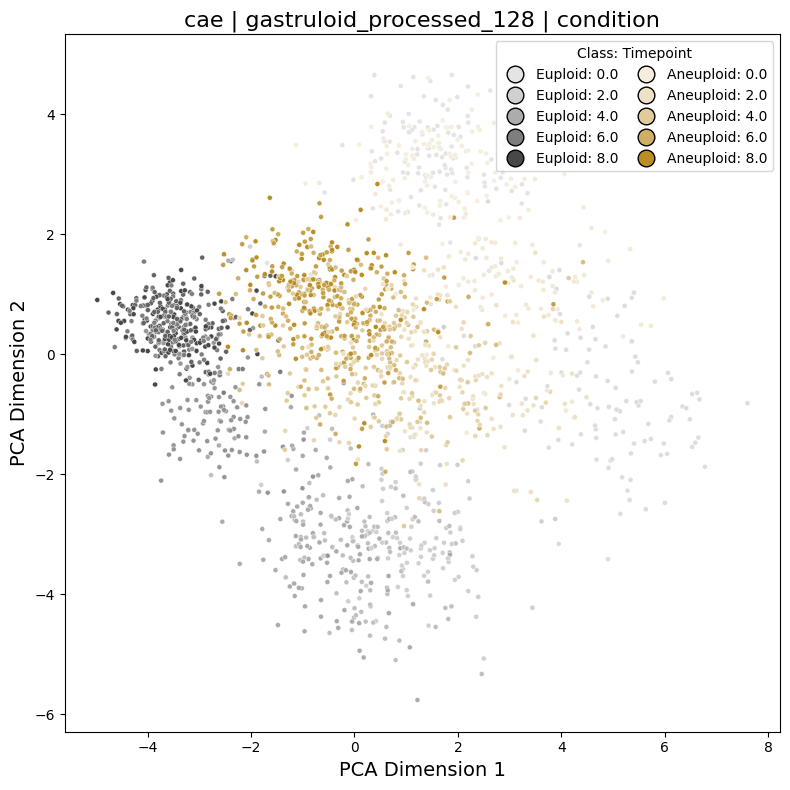

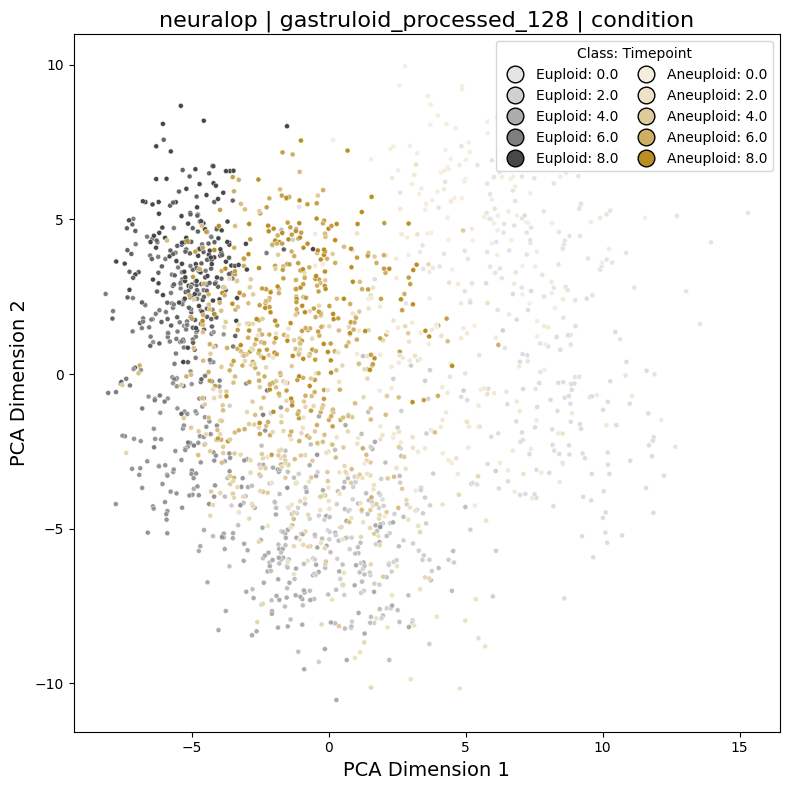

In [37]:
for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():
        pca_embedding = pca_embeddings[model_name][dataset_name]
        color_array_num = np.array(array_nums[model_name][dataset_name])
        timepoint_vals = np.array(timepoints[model_name][dataset_name])
        
        df = pd.DataFrame({
            'PC_0': pca_embedding[:, 0],
            'PC_1': pca_embedding[:, 1],
            'class': ['Euploid' if c == 1 else 'Aneuploid' for c in color_array_num],
            'timepoint': timepoint_vals
        })
        
        class1_base = mcolors.to_rgb(base_colors[1])
        class2_base = mcolors.to_rgb(base_colors[2])
        
        class1_cmap = create_colormap(class1_base)
        class2_cmap = create_colormap(class2_base)
        
        fig, ax = plt.subplots(figsize=(8, 8))
        
        # Store the legend handles and labels for each class
        all_handles = []
        all_labels = []
        
        # Plot each class and collect legend info
        for class_name, cmap in [('Euploid', class1_cmap), ('Aneuploid', class2_cmap)]:
            subset = df[df['class'] == class_name]
            if len(subset) > 0:
                # Create a discrete set of timepoints for the legend
                timepoint_vals_unique = np.sort(subset['timepoint'].unique())
                n_timepoints = min(5, len(timepoint_vals_unique))
                legend_timepoints = np.linspace(
                    timepoint_vals_unique.min(), 
                    timepoint_vals_unique.max(), 
                    n_timepoints
                )
                
                scatter = sns.scatterplot(
                    data=subset,
                    x='PC_0',
                    y='PC_1',
                    hue='timepoint',
                    palette=cmap,
                    s=13,
                    legend=False,
                    ax=ax
                )
                
                norm = plt.Normalize(
                    timepoint_vals_unique.min(),
                    timepoint_vals_unique.max()
                )
                
                for tp in legend_timepoints:
                    color = cmap(norm(tp))
                    handle = plt.Line2D(
                        [0], [0], 
                        marker='o', 
                        color='none',
                        markerfacecolor=color, 
                    )
                    all_handles.append(handle)
                    all_labels.append(f"{class_name}: {tp:.1f}")
        

        legend = ax.legend(
            all_handles, all_labels,
            title='Class: Timepoint',
            loc='upper right', 
            ncol=2, 
            columnspacing=1.0,
            frameon=True,
            handletextpad=0.5
        )
        
        for handle in legend.legend_handles:
            handle.set_markersize(12)
        
        ax.set_title(f"{model_name} | {dataset_name} | condition",
                    fontsize=16)
        ax.set_xlabel('PCA Dimension 1', fontsize=14)
        ax.set_ylabel('PCA Dimension 2', fontsize=14)
        plt.tight_layout()
        plt.show()

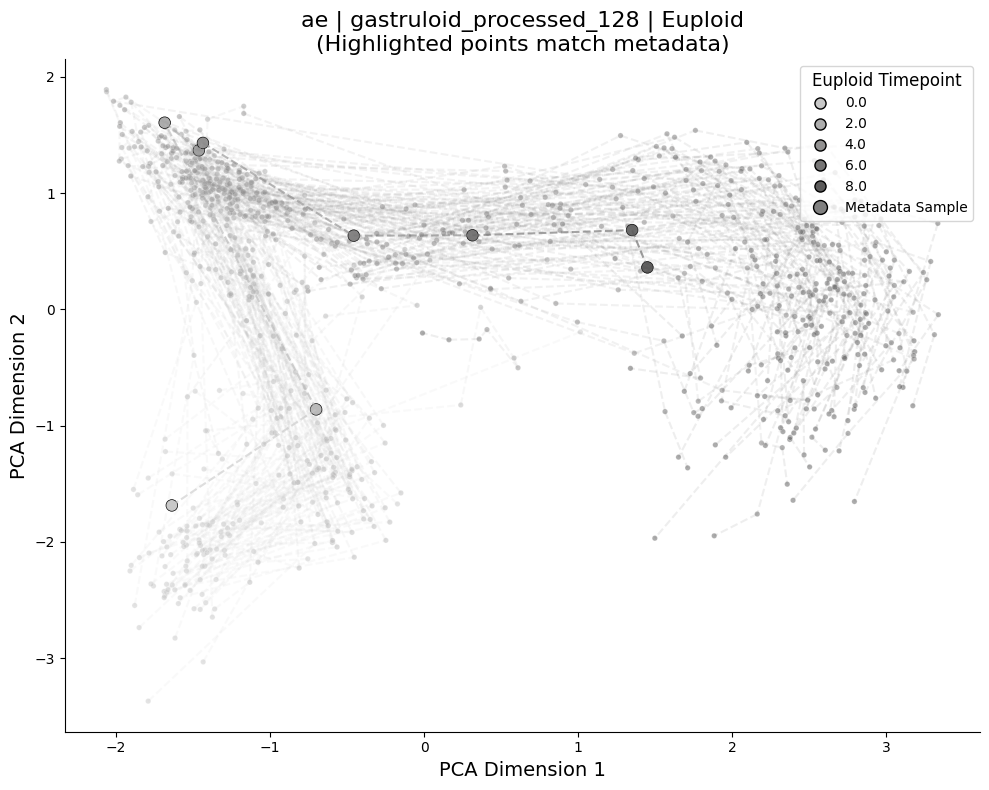

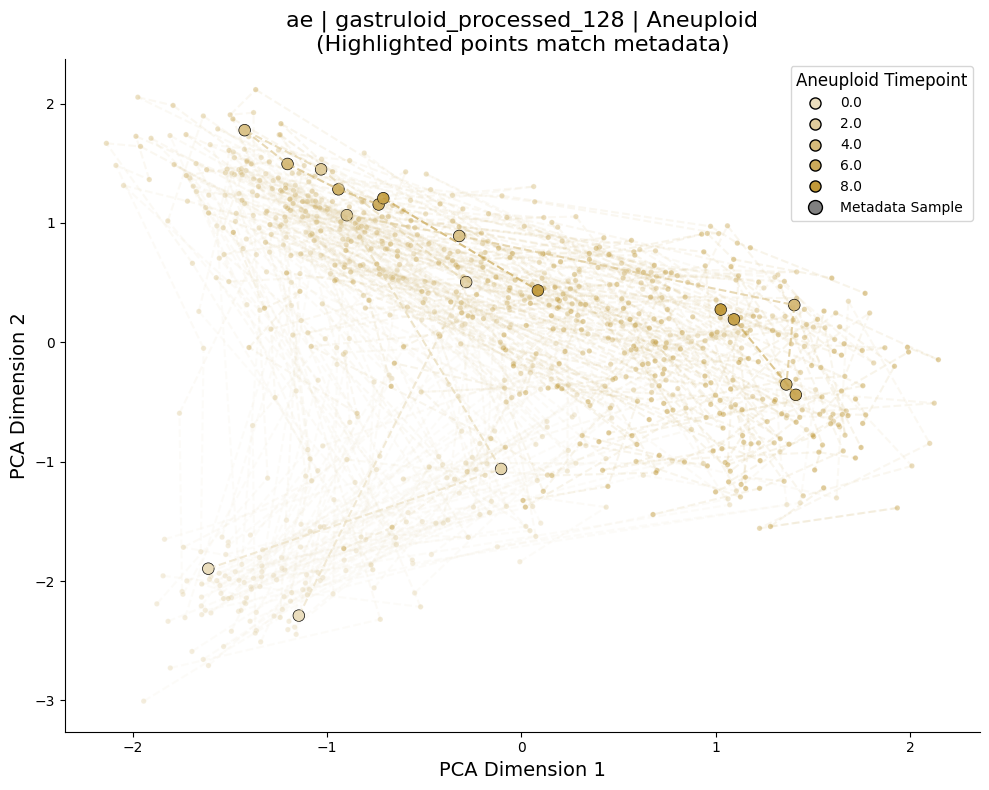

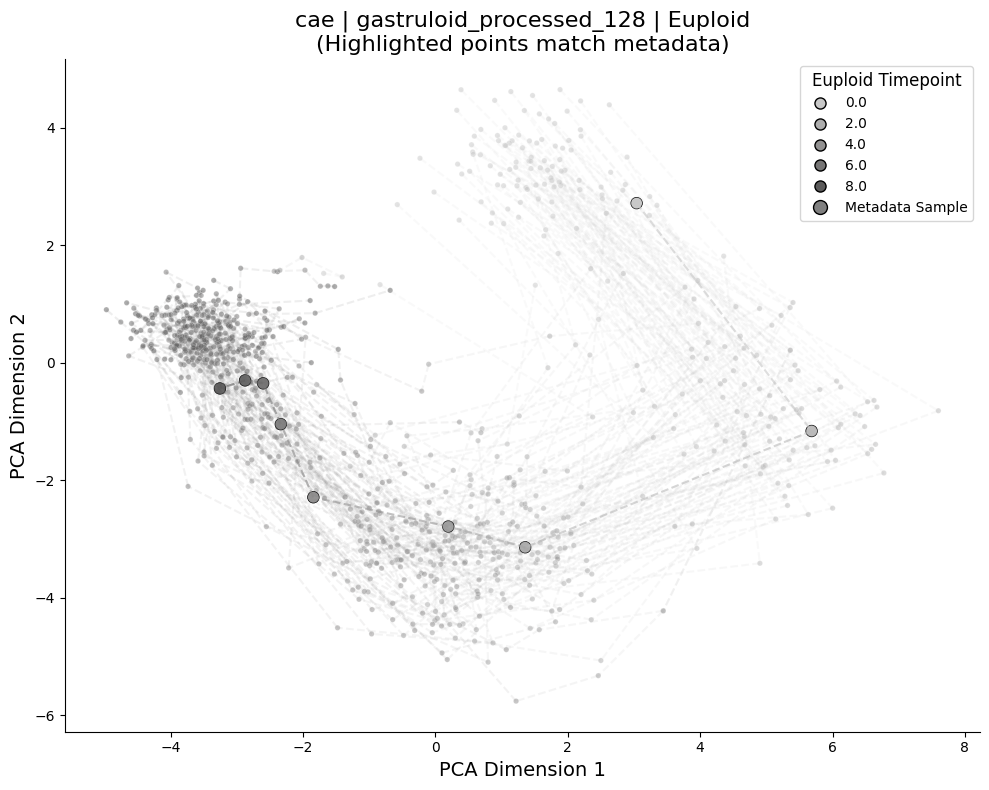

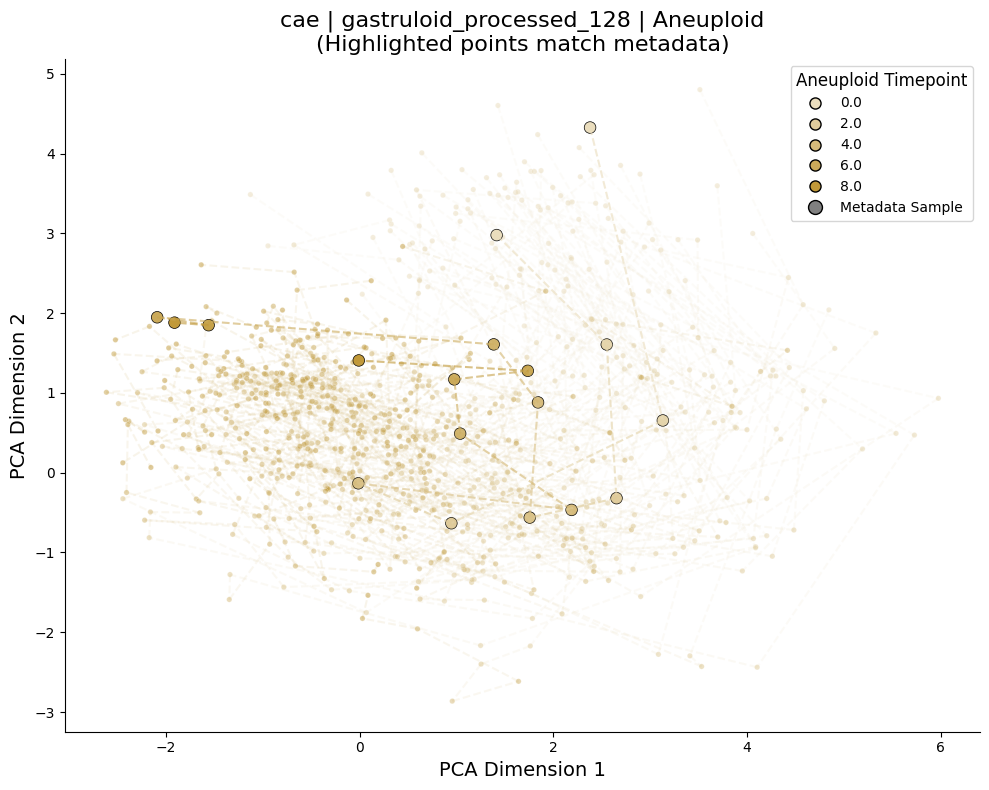

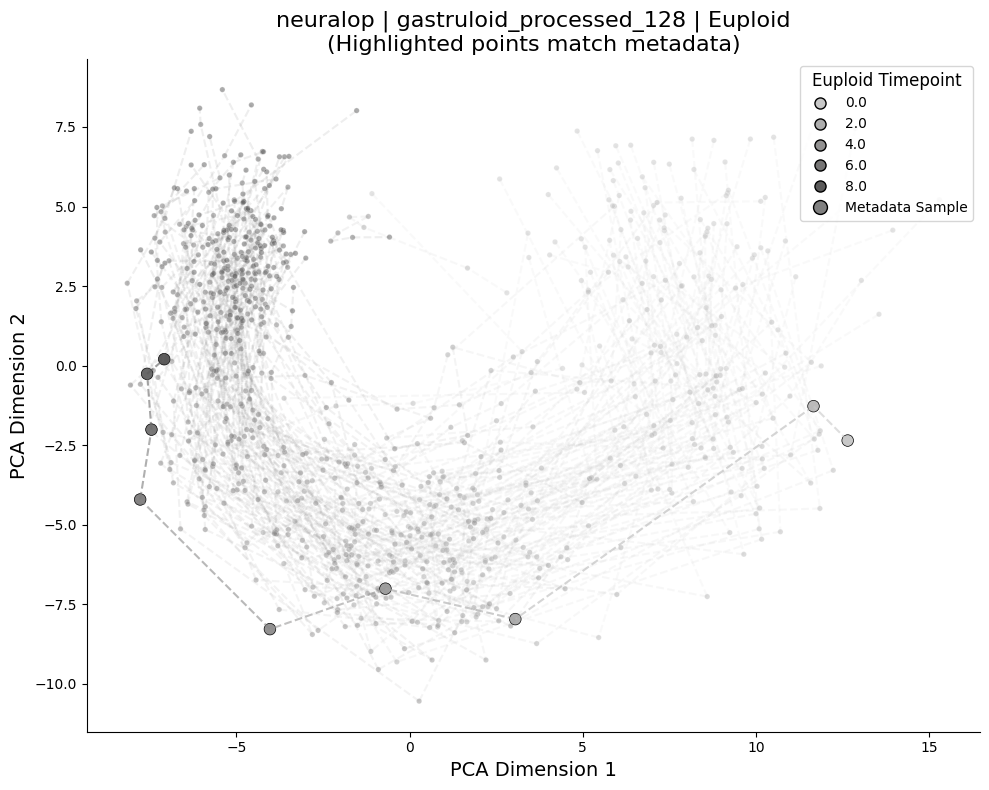

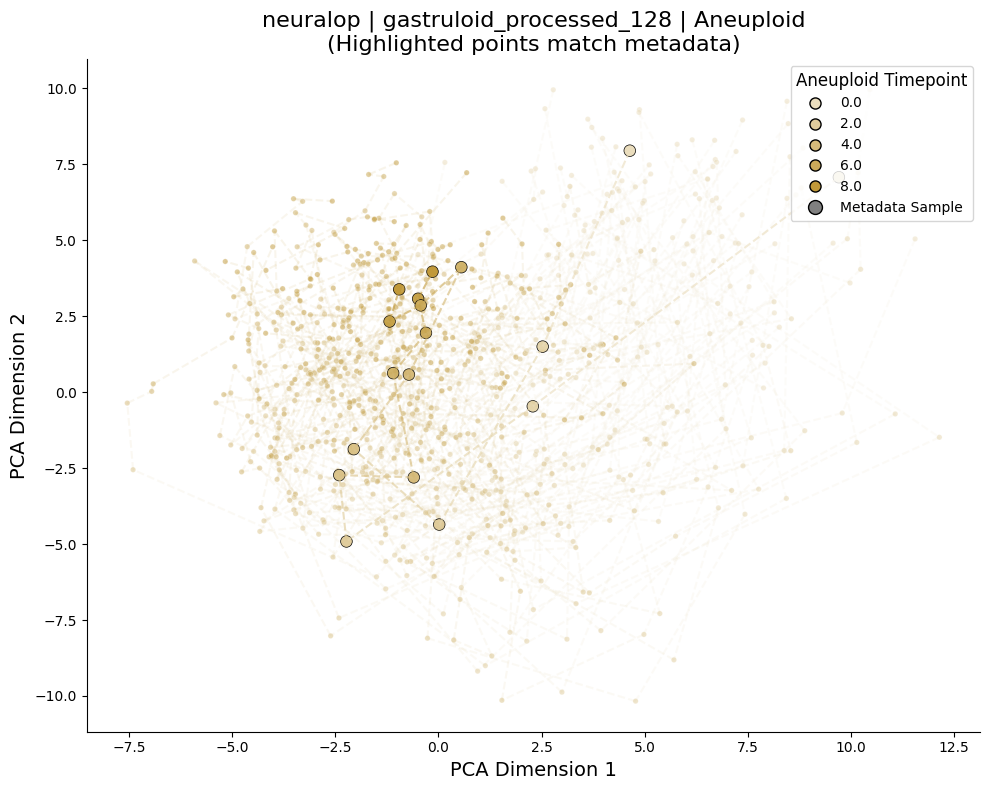

In [38]:
sequencing_metadata = pd.read_csv("metadata/gastruloid_seq_mapping.csv")
sequencing_metadata = sequencing_metadata[sequencing_metadata["Plate"] == 1]
sequencing_metadata["Raft"] = sequencing_metadata["Raft"].astype(int)
metadata_identifiers = metadata_identifiers = set(sequencing_metadata['Condition'] + '_' + sequencing_metadata['Raft'].astype(str))

for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():
        pca_embedding = pca_embeddings[model_name][dataset_name]
        timepoint_vals = np.array(timepoints[model_name][dataset_name])
        raft_id_vals = np.array(raft_ids[model_name][dataset_name])
        
        df = pd.DataFrame({
            'PC_0': pca_embedding[:, 0],
            'PC_1': pca_embedding[:, 1],
            'class': ['Euploid' if c == 1 else 'Aneuploid' for c in color_array_num], 
            'timepoint': timepoint_vals,
            'raft_id': raft_id_vals
        })
        df['identifier'] = df['class'] + '_' + df['raft_id'].astype(str)
        df['is_highlighted'] = df['identifier'].isin(metadata_identifiers)

        class_colors = {
            "Euploid": base_colors[1], 
            "Aneuploid": base_colors[2]
        }

        for class_name in ["Euploid", "Aneuploid"]:
            subset = df[df["class"] == class_name].copy()
            if subset.empty:
                continue

            class_base = mcolors.to_rgb(class_colors[class_name])
            class_cmap = ListedColormap([
                [min(1.0, c + (1 - c) * (0.7 - 0.6 * t)) for c in class_base]
                for t in np.linspace(0, 1, 256)
            ])

            fig, ax = plt.subplots(figsize=(10, 8))
            all_handles = []
            all_labels = []

            unique_raft_ids = subset["raft_id"].unique()
            for raft_id in unique_raft_ids:
                raft_data = subset[subset["raft_id"] == raft_id].sort_values("timepoint")
                if len(raft_data) > 1:
                    line_alpha = 0.4
                    line_alpha = 0.6 if raft_data['is_highlighted'].any() else 0.1
                    
                    colorline(
                        raft_data["PC_0"].values, 
                        raft_data["PC_1"].values, 
                        z=raft_data["timepoint"].values,
                        cmap=class_cmap,
                        linewidth=1.5,
                        alpha=line_alpha,
                    )
            
            highlight_size = 70
            normal_size = 15
            highlight_alpha = 1.0
            normal_alpha = 0.5
            
            subset['size'] = subset['is_highlighted'].map({True: highlight_size, False: normal_size})
            subset['alpha'] = subset['is_highlighted'].map({True: highlight_alpha, False: normal_alpha})

            non_highlighted_subset = subset[~subset['is_highlighted']]
            if not non_highlighted_subset.empty:
                 sns.scatterplot(
                    data=non_highlighted_subset,
                    x="PC_0",
                    y="PC_1",
                    hue="timepoint",
                    palette=class_cmap,
                    s=normal_size,
                    alpha=normal_alpha,
                    legend=False,
                    ax=ax
                )

            highlighted_subset = subset[subset['is_highlighted']]
            if not highlighted_subset.empty:
                sns.scatterplot(
                    data=highlighted_subset,
                    x="PC_0",
                    y="PC_1",
                    hue="timepoint",
                    palette=class_cmap,
                    s=highlight_size,
                    alpha=highlight_alpha,
                    edgecolor='black',
                    linewidth=0.5,
                    legend=False,
                    ax=ax
                )

            timepoint_vals_unique = np.sort(subset["timepoint"].unique())
            if len(timepoint_vals_unique) > 0:
                 min_tp = timepoint_vals_unique.min()
                 max_tp = timepoint_vals_unique.max()
                 norm = plt.Normalize(min_tp, max_tp)
                 
                 n_legend_items = min(5, len(timepoint_vals_unique))
                 if max_tp == min_tp:
                     legend_timepoints = [min_tp]
                 else:
                     legend_timepoints = np.linspace(min_tp, max_tp, n_legend_items)

                 for tp in legend_timepoints:
                     color = class_cmap(norm(tp))
                     handle = plt.Line2D(
                         [0], [0], 
                         marker="o", 
                         color="none",
                         markerfacecolor=color, 
                         markersize=8
                     )
                     all_handles.append(handle)
                     all_labels.append(f"{tp:.1f}")

                 legend_title = f"{class_name} Timepoint"
            else:
                 legend_title = f"{class_name} (No time data)"


            highlight_handle = plt.Line2D(
                [0], [0], marker='o', color='none',
                markerfacecolor='grey', markeredgecolor='black',
                markersize=10, label='Metadata Sample'
            )
            if subset['is_highlighted'].any():
                 all_handles.append(highlight_handle)
                 all_labels.append('Metadata Sample')


            ax.legend(
                all_handles, all_labels,
                title=legend_title, 
                loc="upper right", 
                ncol=1,
                frameon=True,
                fontsize=10,
                title_fontsize=12
            )

            ax.set_title(f"{model_name} | {dataset_name} | {class_name}\n(Highlighted points match metadata)", fontsize=16)
            ax.set_xlabel("PCA Dimension 1", fontsize=14)
            ax.set_ylabel("PCA Dimension 2", fontsize=14)
            plt.tight_layout()
            sns.despine()
            plt.show()

In [39]:
counts_file = ""
mapping_file = "" 
top_n_genes = 20

counts_df = pd.read_csv(counts_file, sep="\t", index_col=0)
mapping_df = pd.read_csv(mapping_file, sep=",", index_col=0)

metadata_plate1 = mapping_df[mapping_df["Plate"] == 1].copy()

condition_code_map = {'Euploid': '1', 'Aneuploid': '2'}
condition_abbr_map = {'Euploid': 'EU', 'Aneuploid': 'AN'}

rename_map = {}
original_columns_to_keep = []

for index, row in metadata_plate1.iterrows():
    plate = row['Plate']
    well = row['Well']
    condition = row['Condition']
    raft = row['Raft']

    condition_abbr = condition_abbr_map[condition]
    sequencing_col_name = f"Plate{plate}-{condition_abbr}-{well}"

    condition_code = condition_code_map[condition]
    image_col_name = f"raft{condition_code}_{raft}"

    rename_map[sequencing_col_name] = image_col_name
    original_columns_to_keep.append(sequencing_col_name)

gene_info_cols = ['chrom', 'start', 'end', 'strand', 'gene_id', 'gene_name', 'gene_type']
existing_gene_info_cols = [col for col in gene_info_cols if col in counts_df.columns]

cols_to_select = existing_gene_info_cols + original_columns_to_keep
filtered_counts_df = counts_df[cols_to_select].copy()

FileNotFoundError: [Errno 2] No such file or directory: ''